In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn import linear_model
from sklearn import svm
from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression

from tools import *
import os
import warnings
warnings.filterwarnings("ignore")
import dill
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel
import zsx_some_tools as st
import zsx_facile_heatmap as fh

In [38]:
def cat_dataset(train_pos_data_, train_neg_data_, val_pos_data_, val_neg_data_, balance=True, seed=42):
    def _produce_data(pos_, neg_):
        pos_.loc[:, 'label'] = 1
        neg_.loc[:, 'label'] = 0
        data_ = pd.concat([pos_, neg_])

        return data_

    # balance sampling
    if balance:
        random.seed(seed)
        
        num1 = train_pos_data_.shape[0]
        num2 = train_neg_data_.shape[0]
        if num1 == num2:
            pass
        elif num1 > num2:
            sample_id = random.sample(list(range(num1)), num2)
            train_pos_data_ = train_pos_data_.iloc[sample_id]
        else:
            sample_id = random.sample(list(range(num2)), num1)
            train_neg_data_ = train_neg_data_.iloc[sample_id]
            
        num1 = val_pos_data_.shape[0]
        num2 = val_neg_data_.shape[0]
        if num1 == num2:
            pass
        elif num1 > num2:
            sample_id = random.sample(list(range(num1)), num2)
            val_pos_data_ = val_pos_data_.iloc[sample_id]
        else:
            sample_id = random.sample(list(range(num2)), num1)
            val_neg_data_ = val_neg_data_.iloc[sample_id]

    # cat dataset
    train_data_ = _produce_data(train_pos_data_, train_neg_data_)
    val_data_ = _produce_data(val_pos_data_, val_neg_data_)

    return train_data_, val_data_

In [39]:
def get_dataset(pos_data_, neg_data_, balance=True,
                train_val_test=(0.8, 0.1, 0.1), seed=42):

    if train_val_test[0] == 0 or (train_val_test[1] == 0 and train_val_test[2] > 0):
        raise ValueError('train_val_test is not suitable, please reset. e.g. (0.8, 0.1, 0.1)')

    def _produce_data(pos_, neg_):
        pos_.loc[:, 'label'] = 1
        neg_.loc[:, 'label'] = 0
        data_ = pd.concat([pos_, neg_])

        return data_

    # compute split ratio
    train_ratio = train_val_test[0]
    test_ratio = train_val_test[2]
    rest_ratio = 1 - train_ratio
    if test_ratio > 0:
        rest_ratio2 = test_ratio / rest_ratio
    else:
        rest_ratio2 = 0

    # balance sampling
    if balance:
        num1 = pos_data_.shape[0]
        num2 = neg_data_.shape[0]
        if num1 == num2:
            pass
        elif num1 > num2:
            sample_id = random.sample(list(range(num1)), num2)
            pos_data_ = pos_data_.iloc[sample_id]
        else:
            sample_id = random.sample(list(range(num2)), num1)
            neg_data_ = neg_data_.iloc[sample_id]

    # split dataset
    if train_ratio == 1:
        train_data_ = _produce_data(pos_data_, neg_data_)
        return train_data_, None, None

    else:
        train_data_pos, test_val_pos = train_test_split(pos_data_, test_size=rest_ratio, random_state=seed)
        train_data_neg, test_val_neg = train_test_split(neg_data_, test_size=rest_ratio, random_state=seed)
        if rest_ratio2:
            val_data_pos, test_data_pos = train_test_split(test_val_pos, test_size=rest_ratio2, random_state=seed)
            val_data_neg, test_data_neg = train_test_split(test_val_neg, test_size=rest_ratio2, random_state=seed)

            test_data_ = _produce_data(test_data_pos, test_data_neg)

        else:
            val_data_pos = test_val_pos
            val_data_neg = test_val_neg
            test_data_ = None

        train_data_ = _produce_data(train_data_pos, train_data_neg)
        val_data_ = _produce_data(val_data_pos, val_data_neg)

        return train_data_, val_data_, test_data_

In [40]:
def pred_and_plot(data_1, data_0, feature, feature_name, model_type='RF', balance=True, train_val_test=(0.7, 0.3, 0), seed=42):
    np.random.seed(seed)
    data_1_choose_feature = data_1.loc[:, feature].copy()
    data_0_choose_feature = data_0.loc[:, feature].copy()
    train_data, val_data, test_data = get_dataset(data_1_choose_feature, data_0_choose_feature, 
                                                  balance=balance, train_val_test=train_val_test, seed=seed)

    x_train, y_train = train_data.iloc[:, :-1], train_data.iloc[:, -1]
    x_valid, y_valid = val_data.iloc[:, :-1], val_data.iloc[:, -1]
    
    if model_type == 'RF':
        np.random.seed(seed)
        model = RandomForestClassifier(200, class_weight='balanced')  # , random_state=seed
        model.fit(x_train, y_train)
        pred_prob_1 = model.predict_proba(x_valid)[:, 1]
    
    elif model_type == 'SVM':
        np.random.seed(seed)
        model = svm.SVC(C=0.2, kernel='linear', decision_function_shape='ovr')
        model.fit(x_train, y_train)
        pred_prob_1 = model.decision_function(x_valid)
    
    true_label = np.array(y_valid)
    valid_result = pd.DataFrame([pred_prob_1, true_label]).T.sort_values(0, ascending=True)
    acc_total = []
    cut_off_total = []
    for i in range(1000):
        cut_off = i / 1000
        acc = sum((valid_result.iloc[:, 0] > cut_off) * 1 == valid_result.iloc[:, 1]) / valid_result.shape[0]
        cut_off_total.append(cut_off)
        acc_total.append(acc)
    
    best_cut_off = cut_off_total[np.argmax(acc_total)]
    conf_mat = confusion_matrix(valid_result.iloc[:, 1], (valid_result.iloc[:, 0] > best_cut_off) * 1)
    conf_p = np.array([conf_mat[:, i] / sum(conf_mat[:, i]) for i in range(conf_mat.shape[0])])
    best_acc = np.mean((valid_result.iloc[:, 0] > best_cut_off) * 1 == valid_result.iloc[:, 1])
    
    plt.figure(figsize=(12, 4))

    plt.subplot(131)
    plt.plot(cut_off_total, acc_total)
    plt.title('best cut_off value : ' + str(cut_off_total[np.argmax(acc_total)]))

    plt.subplot(132)
    roc_curve(valid_result.iloc[:, 1], valid_result.iloc[:, 0], 1)
    
    plt.subplot(133)
    fh.facile_heatmap(plt, conf_p, canvas=False, islabel=False, show_values=True)
    plt.title('best acc: ' + str(np.round(best_acc, 3)))
    print('model: ' + model_type + '    balance: ' + str(balance) + '    feature: ' + str(feature_name))
    plt.suptitle('model: ' + model_type + '    balance: ' + str(balance) + '    feature: ' + str(feature_name))
#     print('confusion matrix:')
#     print(conf_mat[0, 0], conf_mat[0, 1])
#     print(conf_mat[1, 0], conf_mat[1, 1])

# 1.变量筛选

In [41]:
feature_lasso = [ "Megamonas_funiformis",
    "Mediterraneibacter_gnavus",
    "Alistipes_onderdonkii",
    "Faecalibacterium_prausnitzii",
    "Bacteroides_ovatus",
    "Klebsiella_aerogenes",
    "Bifidobacterium_breve",
    "Hungatella_hathewayi",
    "Lacticaseibacillus_paracasei",
    "Streptococcus_lactarius",
    "Enterococcus_faecalis",
    "Bifidobacterium_pseudocatenulatum",
       'Aspergillus_viridinutans', 'Scheffersomyces_stipitis',
       'Aspergillus_nomiae', 'Neurospora_tetrasperma']

In [6]:
len(feature_lasso)

16

# 绘制所有模型的AUROC曲线

In [45]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
from sklearn.model_selection import KFold, GridSearchCV
from xgboost import XGBClassifier

# 设置随机种子
seed = 53
np.random.seed(seed)

# 加载数据
data_raw = st.read_file('E:/projects/肝移植/fig5/术前.txt', index_col=0)
data_raw = data_raw.loc[:, np.std(data_raw, axis=0) != 0]
# 分组数据
data_1 = data_raw.loc[data_raw.loc[:, 'Group'] == 1, data_raw.columns[:-1]]
data_0 = data_raw.loc[data_raw.loc[:, 'Group'] == 0, data_raw.columns[:-1]]

# 存储结果的列表
results = []
all_roc_data = []  # 用于存储所有模型和变量组合的 ROC 数据

# 定义模型和特征
model_dict = {
    'RF': RandomForestClassifier(random_state  = seed),
    'GBM': GradientBoostingClassifier(random_state = seed),
    'XGB': XGBClassifier(use_label_encoder=False, eval_metric='logloss',seed = seed),
    'Lasso': LogisticRegression(penalty='l1', solver='liblinear'),
    'SVM': SVC(probability=True,random_state = seed),
    'QDA': QuadraticDiscriminantAnalysis(),
    'Logistic Regression': LogisticRegression()
}

features_list = [[feature_lasso, 'gene']]

# 定义线型和颜色
linestyles = ['-', '-', '-', '-', (0, (3, 1, 1, 1)), (0, (5, 10))]  # 不同模型的线型
colors = sns.color_palette("hsv", len(features_list))  # 使用 seaborn 提供的颜色调色板

import os

# 目标目录路径
output_dir = r'D:\projects\jupyter\移植\prediction\val\micro\t0'

# 确保目录存在
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 在训练后保存每个模型
for model_idx, (model_name, model) in enumerate(model_dict.items()):
    for feature_idx, (feature, feature_name) in enumerate(features_list):
        for balance in [True, False]:
            fold_aucs = []  # 用于存储每一折的 AUC
            fold_accs = []  # 用于存储每一折的准确率

            print(f"模型类型: {model_name}, 平衡: {balance}, 特征: {feature_name}")

            # 创建 10 折交叉验证
            kf_pos = KFold(n_splits=10, shuffle=True, random_state=seed)
            kf_neg = KFold(n_splits=10, shuffle=True, random_state=seed)

            # 用于存储所有折的预测概率和真实标签
            all_pred_probs = []
            all_true_labels = []

            # 交叉验证的训练过程
            for fold_idx, ((train_index_pos, val_index_pos), (train_index_neg, val_index_neg)) in enumerate(zip(kf_pos.split(data_1), kf_neg.split(data_0))):
                # 分别获取正样本和负样本的训练集和验证集
                train_data_pos = data_1.iloc[train_index_pos]
                val_data_pos = data_1.iloc[val_index_pos]

                train_data_neg = data_0.iloc[train_index_neg]
                val_data_neg = data_0.iloc[val_index_neg]

                # 使用 cat_dataset 获取训练集、验证集
                train_data, val_data = cat_dataset(train_data_pos, train_data_neg, val_data_pos, val_data_neg, balance=balance, seed=seed)

                # 提取特征和标签
                x_train = train_data[feature]
                y_train = train_data['label']
                x_val = val_data[feature]
                y_val = val_data['label']

                # 使用模型训练
                model.fit(x_train, y_train)

                # 进行预测
                y_pred_prob = model.predict_proba(x_val)[:, 1]  # 获取预测的概率，用于 AUC 计算

                # 存储预测的概率和真实标签用于汇总
                all_pred_probs.extend(y_pred_prob)
                all_true_labels.extend(y_val)

            # 计算 ROC 曲线和 AUC
            fpr, tpr, _ = roc_curve(all_true_labels, all_pred_probs)
            roc_auc = roc_auc_score(all_true_labels, all_pred_probs)

            # 存储所有模型的 ROC 数据
            all_roc_data.append({
                'fpr': fpr,
                'tpr': tpr,
                'model_name': model_name,
                'feature_name': feature_name,
                'balance': balance,
                'roc_auc': roc_auc,
                'linestyle': linestyles[model_idx % len(linestyles)],
                'color': colors[feature_idx % len(colors)]
            })

            # 打印平均 AUC
            print(f"特征: {feature_name}, 模型: {model_name}, 平衡: {balance}, 10折平均 AUC: {roc_auc:.2f}")

            # 保存模型
            model_filename = f"{model_name}_{feature_name}_{'balanced' if balance else 'unbalanced'}.pkl"
            model_filepath = os.path.join(output_dir, model_filename)  # 拼接保存路径
            joblib.dump(model, model_filepath)
            print(f"模型已保存为 {model_filepath}")

            # 记录结果
            results.append({
                'feature_name': feature_name,
                'model_type': model_name,
                'balance': balance,
                'avg_auc': roc_auc
            })

模型类型: RF, 平衡: True, 特征: gene
特征: gene, 模型: RF, 平衡: True, 10折平均 AUC: 0.56
模型已保存为 D:\projects\jupyter\移植\prediction\val\micro\t0\RF_gene_balanced.pkl
模型类型: RF, 平衡: False, 特征: gene
特征: gene, 模型: RF, 平衡: False, 10折平均 AUC: 0.60
模型已保存为 D:\projects\jupyter\移植\prediction\val\micro\t0\RF_gene_unbalanced.pkl
模型类型: GBM, 平衡: True, 特征: gene
特征: gene, 模型: GBM, 平衡: True, 10折平均 AUC: 0.56
模型已保存为 D:\projects\jupyter\移植\prediction\val\micro\t0\GBM_gene_balanced.pkl
模型类型: GBM, 平衡: False, 特征: gene
特征: gene, 模型: GBM, 平衡: False, 10折平均 AUC: 0.60
模型已保存为 D:\projects\jupyter\移植\prediction\val\micro\t0\GBM_gene_unbalanced.pkl
模型类型: XGB, 平衡: True, 特征: gene
特征: gene, 模型: XGB, 平衡: True, 10折平均 AUC: 0.50
模型已保存为 D:\projects\jupyter\移植\prediction\val\micro\t0\XGB_gene_balanced.pkl
模型类型: XGB, 平衡: False, 特征: gene
特征: gene, 模型: XGB, 平衡: False, 10折平均 AUC: 0.56
模型已保存为 D:\projects\jupyter\移植\prediction\val\micro\t0\XGB_gene_unbalanced.pkl
模型类型: Lasso, 平衡: True, 特征: gene
特征: gene, 模型: Lasso, 平衡: True, 10折平均 AUC: 0.61
模型已保存为 D:

In [46]:
import zsx_some_tools as st
st.write_file('E:/projects/肝移植/metab/prediction/micro_t0_roc_data.pkl', all_roc_data)
print("10折交叉验证结果:")
#print(results_df)

10折交叉验证结果:


已加载模型: D:\projects\jupyter\移植\prediction\val\micro\t0\GBM_gene_balanced.pkl
已加载模型: D:\projects\jupyter\移植\prediction\val\micro\t0\GBM_gene_unbalanced.pkl
已加载模型: D:\projects\jupyter\移植\prediction\val\micro\t0\Lasso_gene_balanced.pkl
已加载模型: D:\projects\jupyter\移植\prediction\val\micro\t0\Lasso_gene_unbalanced.pkl
已加载模型: D:\projects\jupyter\移植\prediction\val\micro\t0\Logistic Regression_gene_balanced.pkl
已加载模型: D:\projects\jupyter\移植\prediction\val\micro\t0\Logistic Regression_gene_unbalanced.pkl
已加载模型: D:\projects\jupyter\移植\prediction\val\micro\t0\QDA_gene_balanced.pkl
已加载模型: D:\projects\jupyter\移植\prediction\val\micro\t0\QDA_gene_unbalanced.pkl
已加载模型: D:\projects\jupyter\移植\prediction\val\micro\t0\RF_gene_balanced.pkl
已加载模型: D:\projects\jupyter\移植\prediction\val\micro\t0\RF_gene_unbalanced.pkl
已加载模型: D:\projects\jupyter\移植\prediction\val\micro\t0\SVM_gene_balanced.pkl
已加载模型: D:\projects\jupyter\移植\prediction\val\micro\t0\SVM_gene_unbalanced.pkl
已加载模型: D:\projects\jupyter\移植\prediction\v

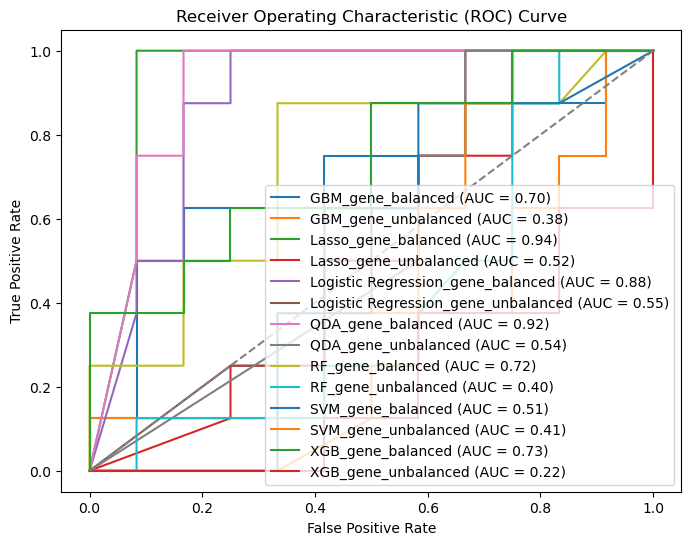

In [36]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 模型文件列表
model_directory = r'D:\projects\jupyter\移植\prediction\val\micro\t0'

# 获取该目录下所有的 .pkl 文件
model_files = [os.path.join(model_directory, f) for f in os.listdir(model_directory) if f.endswith('.pkl')]
# 加载新数据
data_new = st.read_file('E:/projects/肝移植/validation/micro_val_t0.txt', index_col=0)
#data_new = data_new.loc[:, np.std(data_new, axis=0) != 0]
x_new = data_new[feature_lasso]  # 使用相同的特征列

# 设置图形
plt.figure(figsize=(8, 6))

# 遍历模型文件
for model_filename in model_files:
    # 加载模型
    loaded_model = joblib.load(model_filename)
    print(f"已加载模型: {model_filename}")
    
    # 使用模型进行预测
    y_new_pred_prob = loaded_model.predict_proba(x_new)[:, 1]  # 获取预测的概率

    # 计算 ROC 曲线
    fpr, tpr, thresholds = roc_curve(list(data_new['Group']), y_new_pred_prob)
    auc = roc_auc_score(list(data_new['Group']), y_new_pred_prob)

    # 修正路径中的反斜杠
    model_name = model_filename.split('\\')[-1].split('.')[0]

    # 绘制 ROC 曲线
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.2f})")

# 绘制随机猜测的对角线
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# 设置图表标签和标题
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# 显示图形
#plt.show()
plt.savefig('E:/projects/肝移植/validation/pre/micro_t02t0_validation.pdf', dpi=600, bbox_inches='tight', transparent=True)

已加载模型: D:\projects\jupyter\移植\prediction\val\micro\t0\Lasso_gene_balanced.pkl
新数据预测概率: [8.99854700e-092 8.23886761e-001 4.09843056e-167 1.00000000e+000
 1.01334335e-014 1.52889051e-078 1.00000000e+000 2.08337003e-288
 0.00000000e+000 7.12104939e-185 0.00000000e+000 2.60284436e-046
 6.27794953e-001 5.23340089e-001 1.00000000e+000 3.25971083e-003
 5.19125568e-001 1.00000000e+000 1.00000000e+000 9.71727952e-001]


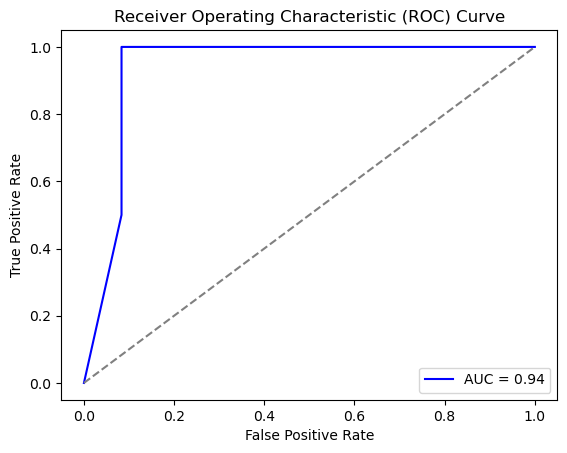

In [43]:
# 加载已保存的模型
model_filename = r'D:\projects\jupyter\移植\prediction\val\micro\t0\Lasso_gene_balanced.pkl'  # 你想加载的模型文件名
loaded_model = joblib.load(model_filename)
print(f"已加载模型: {model_filename}")

data_new = st.read_file('E:/projects/肝移植/validation/micro_val_t0.txt', index_col=0)
#data_new = data_new.loc[:, np.std(data_new, axis=0) != 0]
x_new = data_new[feature_lasso]  # 使用相同的特征列

# 使用加载的模型进行预测
y_new_pred_prob = loaded_model.predict_proba(x_new)[:, 1]  # 获取预测的概率
# 根据需要，你可以打印或保存预测结果
print(f"新数据预测概率: {y_new_pred_prob}")
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# 计算 ROC 曲线
fpr, tpr, thresholds = roc_curve(list(data_new['Group']), y_new_pred_prob)
auc = roc_auc_score(list(data_new['Group']), y_new_pred_prob)
# 绘制 ROC 曲线
plt.plot(fpr, tpr, color='b', label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
#plt.show()
plt.savefig('E:/projects/肝移植/validation/pre/micro_t02t0_validation_Lasso.pdf', dpi=600, bbox_inches='tight', transparent=True)